In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from figures_setup import *
from utils import set_color_code

## Read data: chemotherapy time course

In [3]:
# Read input data
file = os.path.join(dir_data, "Org_chemo_LM3_woCC.h5ad")
adata = sc.read_h5ad(file)

In [4]:
# Import magic imputation results
import utils
utils.import_magic(adata, final_id='Org_chemo_LM3_woCC')

Importing MAGIC results...
4937 missing genes will be added to magic matrix with zero counts.


In [5]:
# Add time annotation
from utils_chemo_timecourse import color_code
import utils_chemo_timecourse as utils_spec

utils_spec.add_time(adata)
utils.set_uns_colors(adata, color_code, 'time')

## UMAP representation

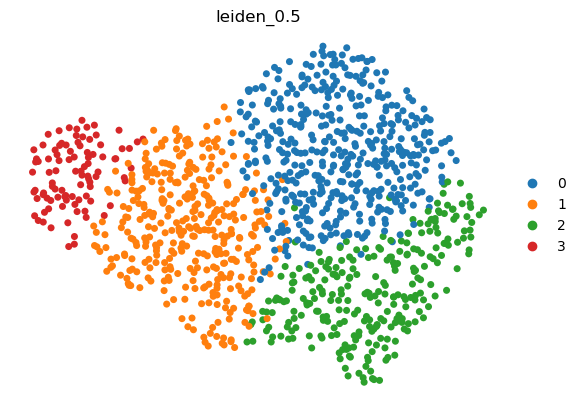

In [8]:
# Annotation UMAP
sc.pl.umap(adata, color=['leiden_0.5'], frameon=False, title=None)

           rel_no_cells                                
leiden_0.5            0          1         2          3
time                                                   
0h             1.869159  12.149533  0.000000  85.981308
12h            0.636943  97.452229  1.910828   0.000000


/tmp/ipykernel_846166/1550272208.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  freq = adata.obs.pivot_table(index='time', columns='leiden_0.5',


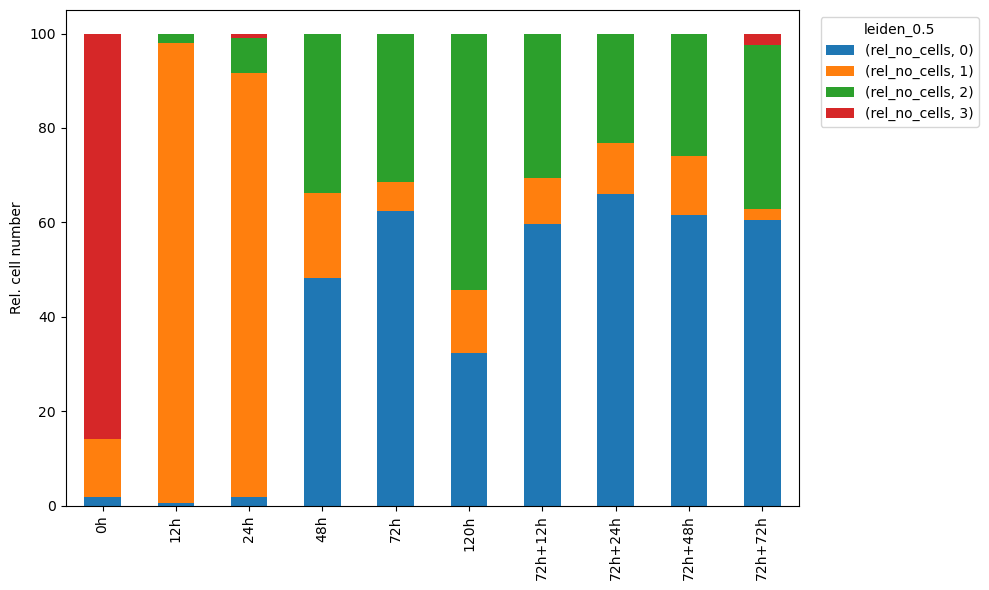

In [21]:
# Get cluster composition
cell_bc = 'cell_bc'
if cell_bc not in adata.obs.columns:
    adata.obs[cell_bc] = adata.obs.index
freq = adata.obs.pivot_table(index='time', columns='leiden_0.5', 
                             values=[cell_bc], aggfunc={cell_bc: 'count'})
# Rename columns
cell_count_label = 'no_cells'
colnames = {cell_bc: cell_count_label,}
freq.rename(columns=colnames, inplace=True)

# Normalize data and write to new object
freq_rel = freq.div(freq.sum(axis=1), axis=0)*100
# Rename columns
cell_count_label = 'rel_no_cells'
colnames = {'no_cells': cell_count_label,}
freq_rel.rename(columns=colnames, inplace=True)

print(freq_rel.head(2))


# df = adata.obs.groupby(['time', 'leiden_0.5']).size().unstack(fill_value=0)
# df = df.div(df.sum(axis=1), axis=0)
# df = df.reset_index().melt(id_vars='time', var_name='leiden_0.5', value_name='proportion')
# df['leiden_0.5'] = df['leiden_0.5'].astype(int) 

# Stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))
freq_rel.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=adata.uns['leiden_0.5_colors'][:freq_rel.shape[1]]
)

ax.set_ylabel('Rel. cell number')
ax.set_xlabel('')
ax.legend(title='leiden_0.5', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

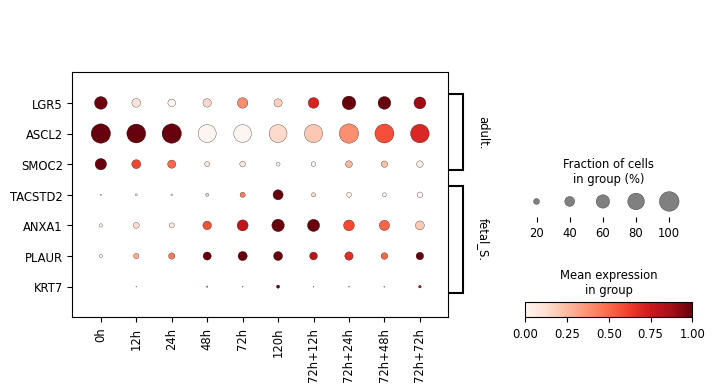

In [23]:
# Make dotplot over feature
marker_genes_dict = {
    "adult_SC": ["LGR5", "ASCL2", 'SMOC2'],
    "fetal_SC": ["TACSTD2", "ANXA1", "PLAUR", "KRT7"],
}

fig, ax = plt.subplots(figsize=(8,4))
sc.pl.dotplot(adata,
                marker_genes_dict,
                groupby='time',
                standard_scale='var',
                swap_axes=True,
                ax=ax,
            )
fig.tight_layout()
fig.show()

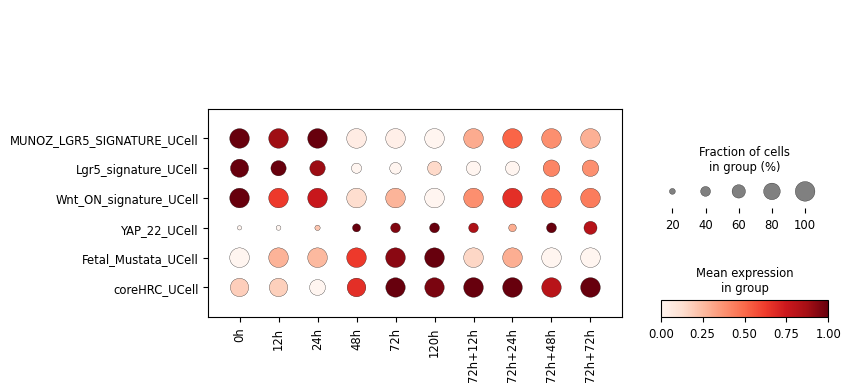

In [28]:
# Make dotplot over feature
feature = 'time'
marker_genesets = [
    'MUNOZ_LGR5_SIGNATURE_UCell',
    'Lgr5_signature_UCell', # used by Rene in current Fig i.
    'Wnt_ON_signature_UCell',
    'YAP_22_UCell',
    'Fetal_Mustata_UCell',
    'coreHRC_UCell',
]

fig, ax = plt.subplots(figsize=(8,4))
sc.pl.dotplot(adata,
                marker_genesets,
                groupby=feature,
                standard_scale='var',
                swap_axes=True,
                ax=ax,
            )
fig.tight_layout()
fig.show()

## DGEA cluster 0 vs cluster 2 (tbc)